# CSE438 Lab 05: Spatial Filtering — Smoothing Filters

**Course:** CSE438 — Digital Image Processing  
**Lab Theme:** Box filtering, Gaussian filtering, median filtering, and noise-removal evaluation  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Classes:** Bacterial Leaf Disease, Dried Leaf, Fungal Brown Spot Disease, Healthy Leaf  
**Platform:** Kaggle Notebook

This lab studies smoothing filters as neighborhood-based operations. Students will add synthetic Gaussian noise to a real Betel Leaf image, apply different smoothing filters, and compare the restored outputs using both visual inspection and numerical metrics.

## Learning Objectives

After completing this lab, students should be able to:

1. apply box and Gaussian smoothing filters to noisy images;
2. explain how kernel size affects the amount of blur;
3. compare linear smoothing filters with nonlinear median filtering;
4. evaluate denoising quality using Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR);
5. interpret the trade-off between noise suppression and edge/detail preservation.

## Lab Tasks

1. Add Gaussian noise to an image.  
2. Apply box filter with varying kernel sizes.  
3. Apply Gaussian filter with varying sigma values.  
4. Apply median filter.  
5. Evaluate filtered outputs using MSE and PSNR.

## 1. Import Required Libraries

The notebook uses OpenCV for spatial filtering, NumPy for numerical computation, pandas for metric tables, and Matplotlib for visualization.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = False

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 2. Dataset Path Configuration for Kaggle

Kaggle may mount the dataset with a slightly different folder name depending on how it is attached to the notebook. The following cell checks common paths first and then searches `/kaggle/input` for a directory containing the required `train` and `test` folders.

In [2]:
EXPECTED_CLASSES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

CANDIDATE_DATASET_PATHS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
    Path("/kaggle/input/rifat963/betel-leaf-image-dataset-from-bangladesh"),
]


def has_required_structure(base_path: Path) -> bool:
    """Return True if the path contains train/test folders and at least one expected class."""
    train_dir = base_path / "train"
    test_dir = base_path / "test"
    if not train_dir.exists() or not test_dir.exists():
        return False
    return any((train_dir / cls).exists() for cls in EXPECTED_CLASSES)


def find_dataset_root() -> Path:
    """Find the dataset root in Kaggle without requiring a hard-coded mount name."""
    for path in CANDIDATE_DATASET_PATHS:
        if has_required_structure(path):
            return path

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.rglob("*"):
            if path.is_dir() and has_required_structure(path):
                return path

    raise FileNotFoundError(
        "Dataset root was not found. Add the Kaggle dataset to this notebook and rerun the cell."
    )

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"
OUTPUT_DIR = Path("/kaggle/working/cse438_lab05_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train folder :", TRAIN_DIR)
print("Test folder  :", TEST_DIR)
print("Output folder:", OUTPUT_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train folder : /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test folder  : /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test
Output folder: /kaggle/working/cse438_lab05_outputs


## 3. Inspect Class Distribution

The following table verifies that the four Betel Leaf classes are available in both `train` and `test` folders.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def list_images(folder: Path):
    """List image files under a folder."""
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS])

rows = []
for cls in EXPECTED_CLASSES:
    train_images = list_images(TRAIN_DIR / cls)
    test_images = list_images(TEST_DIR / cls)
    rows.append({
        "Class": cls,
        "Train Images": len(train_images),
        "Test Images": len(test_images),
    })

count_df = pd.DataFrame(rows)
display(count_df)

,Class,Train Images,Test Images
0,Bacterial Leaf Disease,609,47
1,Dried Leaf,597,51
2,Fungal Brown Spot Disease,588,54
3,Healthy Leaf,594,49


## 4. Helper Functions

These helper functions keep the later cells short and readable. All images are loaded in RGB format for display and resized to a fixed size so that pixel-wise metrics can be computed fairly.

In [4]:
TARGET_SIZE = (512, 512)  # width, height


def load_rgb_image(path: Path, target_size=TARGET_SIZE) -> np.ndarray:
    """Load an image with OpenCV, convert BGR to RGB, and resize it."""
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return rgb


def to_gray(rgb_image: np.ndarray) -> np.ndarray:
    """Convert an RGB image to grayscale."""
    return cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)


def show_images(images, titles, cmap=None, cols=3, figsize=(15, 8)):
    """Display a list of images in a grid."""
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def mse(reference: np.ndarray, candidate: np.ndarray) -> float:
    """Compute Mean Squared Error between two images."""
    diff = reference.astype(np.float32) - candidate.astype(np.float32)
    return float(np.mean(diff ** 2))


def psnr(reference: np.ndarray, candidate: np.ndarray, max_pixel=255.0) -> float:
    """Compute Peak Signal-to-Noise Ratio in decibels."""
    error = mse(reference, candidate)
    if error == 0:
        return float("inf")
    return float(20 * np.log10(max_pixel / np.sqrt(error)))


def save_gray(name: str, image: np.ndarray):
    """Save a grayscale image to the output directory."""
    path = OUTPUT_DIR / name
    cv2.imwrite(str(path), image)
    return path

## 5. Select a Working Image

A single image is selected from the training set. The same clean image will be used as the reference for MSE and PSNR calculation.

Selected image: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
RGB shape: (512, 512, 3) | dtype: uint8
Grayscale shape: (512, 512) | dtype: uint8


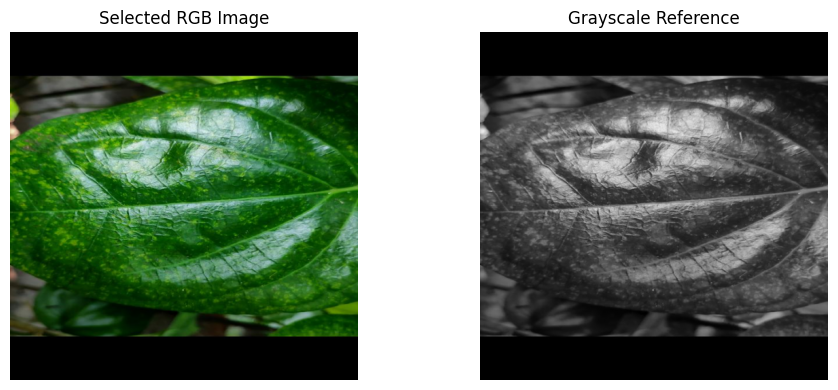

In [5]:
def first_available_image(preferred_class="Healthy Leaf") -> Path:
    """Return one image path from the preferred class; otherwise use the first available class."""
    preferred_images = list_images(TRAIN_DIR / preferred_class)
    if preferred_images:
        return preferred_images[0]

    for cls in EXPECTED_CLASSES:
        images = list_images(TRAIN_DIR / cls)
        if images:
            return images[0]

    raise FileNotFoundError("No image was found in the training folder.")

sample_path = first_available_image("Healthy Leaf")
rgb = load_rgb_image(sample_path)
gray = to_gray(rgb)

print("Selected image:", sample_path)
print("RGB shape:", rgb.shape, "| dtype:", rgb.dtype)
print("Grayscale shape:", gray.shape, "| dtype:", gray.dtype)

show_images([rgb, gray], ["Selected RGB Image", "Grayscale Reference"], cols=2, figsize=(10, 4))

## 6. Task 1 — Add Gaussian Noise

Gaussian noise is generated from a normal distribution and added to the clean grayscale image. The noisy image simulates sensor disturbance, low-light acquisition noise, or image acquisition error.

Gaussian noise sigma: 25
MSE  (clean vs noisy): 520.226
PSNR (clean vs noisy): 20.969 dB


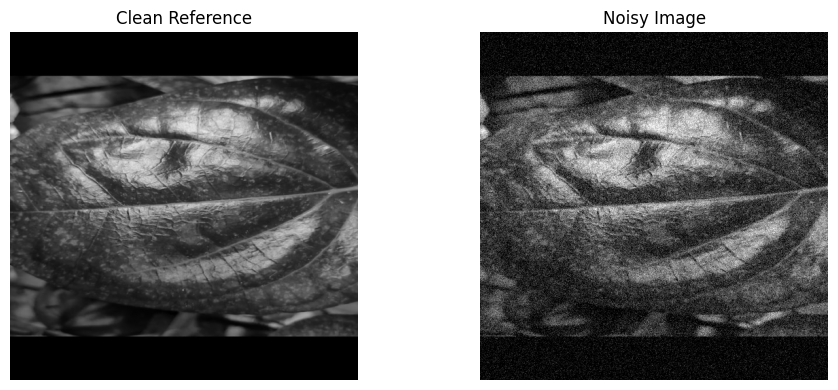

PosixPath('/kaggle/working/cse438_lab05_outputs/02_noisy_gaussian.png')

In [6]:
def add_gaussian_noise(image: np.ndarray, mean=0.0, sigma=25.0, generator=rng) -> np.ndarray:
    """Add zero-mean Gaussian noise to an image and clip the result to [0, 255]."""
    noise = generator.normal(mean, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

NOISE_SIGMA = 25
noisy_gray = add_gaussian_noise(gray, sigma=NOISE_SIGMA)

print(f"Gaussian noise sigma: {NOISE_SIGMA}")
print("MSE  (clean vs noisy):", round(mse(gray, noisy_gray), 3))
print("PSNR (clean vs noisy):", round(psnr(gray, noisy_gray), 3), "dB")

show_images([gray, noisy_gray], ["Clean Reference", "Noisy Image"], cols=2, figsize=(10, 4))

save_gray("01_clean_reference.png", gray)
save_gray("02_noisy_gaussian.png", noisy_gray)

## 7. Visualize Noise Distribution

A histogram helps verify that the added disturbance changes the gray-level distribution. Noise often spreads the histogram and produces local intensity fluctuation.

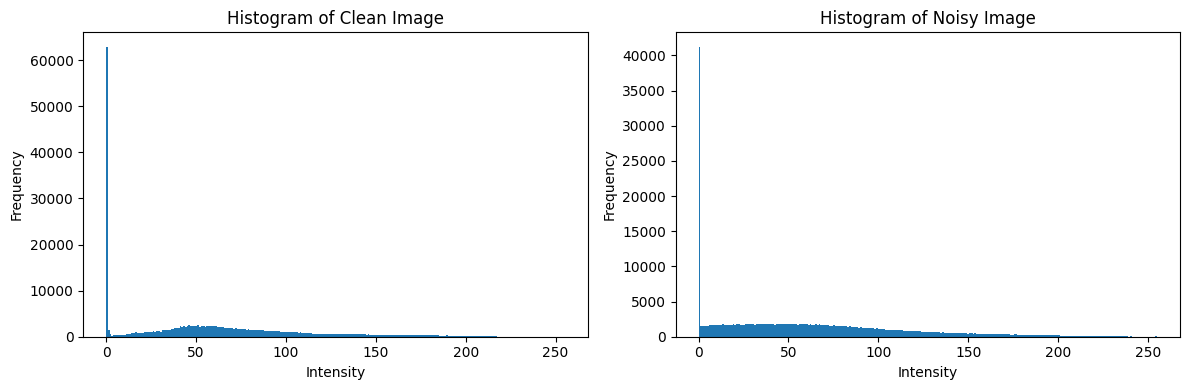

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(gray.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of Clean Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(noisy_gray.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of Noisy Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8. Task 2 — Apply Box Filter with Varying Kernel Sizes

A box filter replaces each pixel with the average value of its local neighborhood. Larger kernels suppress more noise but also blur edges and fine structures of the leaf surface.

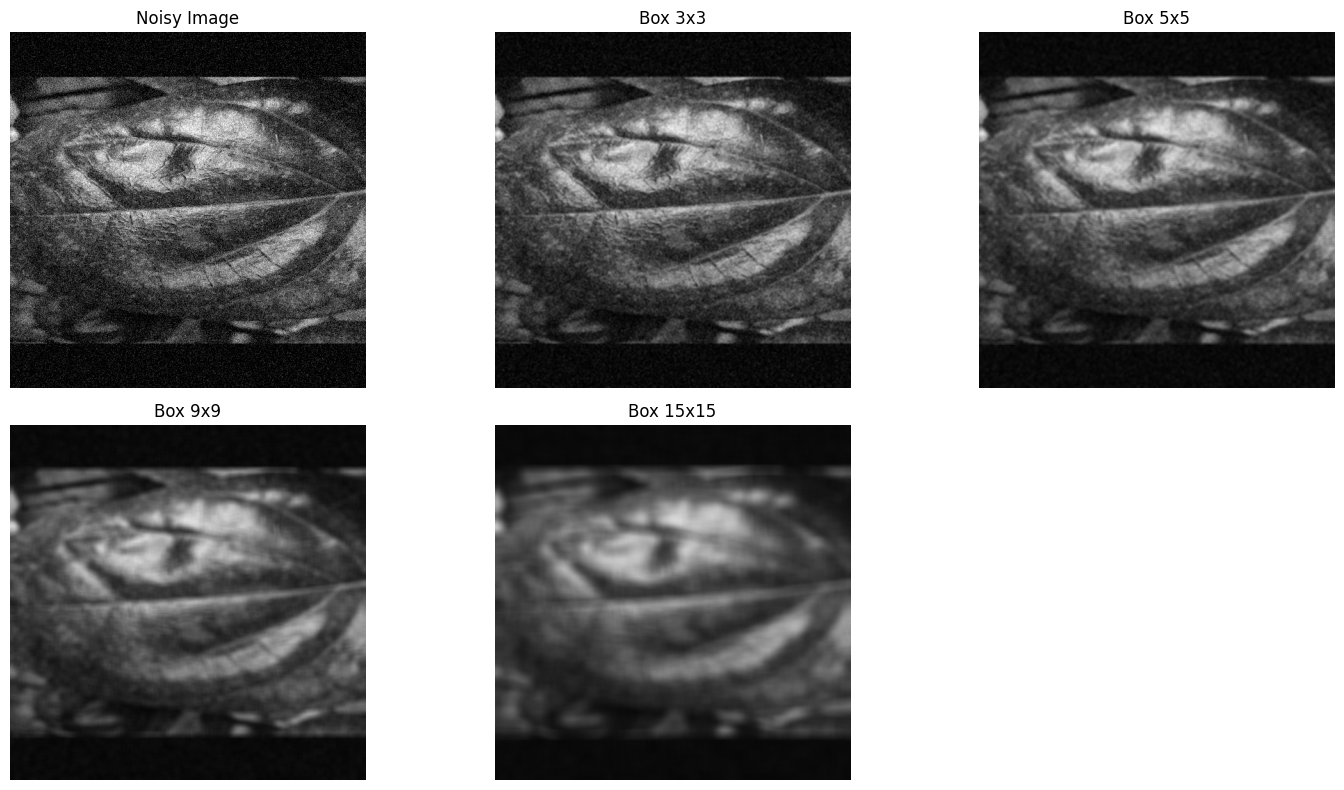

In [8]:
box_kernel_sizes = [3, 5, 9, 15]
box_results = {}

for k in box_kernel_sizes:
    filtered = cv2.blur(noisy_gray, (k, k))
    box_results[f"Box {k}x{k}"] = filtered
    save_gray(f"box_filter_{k}x{k}.png", filtered)

show_images(
    [noisy_gray] + list(box_results.values()),
    ["Noisy Image"] + list(box_results.keys()),
    cols=3,
    figsize=(15, 8),
)

## 9. Box Filter Metric Table

Lower MSE and higher PSNR indicate that the filtered image is closer to the clean reference. However, the best numerical value does not always imply the best visual result because strong smoothing can remove leaf edges and texture.

In [9]:
box_metric_rows = []
for name, img in box_results.items():
    box_metric_rows.append({
        "Method": name,
        "MSE": mse(gray, img),
        "PSNR (dB)": psnr(gray, img),
    })

box_metrics = pd.DataFrame(box_metric_rows).sort_values("PSNR (dB)", ascending=False)
display(box_metrics.style.format({"MSE": "{:.3f}", "PSNR (dB)": "{:.3f}"}))

,Method,MSE,PSNR (dB)
0,Box 3x3,108.652,27.770
1,Box 5x5,112.819,27.607
2,Box 9x9,169.718,25.834
3,Box 15x15,259.687,23.986


## 10. Task 3 — Apply Gaussian Filter with Varying Sigma

A Gaussian filter computes a weighted average where nearer pixels receive larger weights. The parameter `sigma` controls the spatial spread of smoothing. Small sigma values preserve more structure; large sigma values create stronger blur.

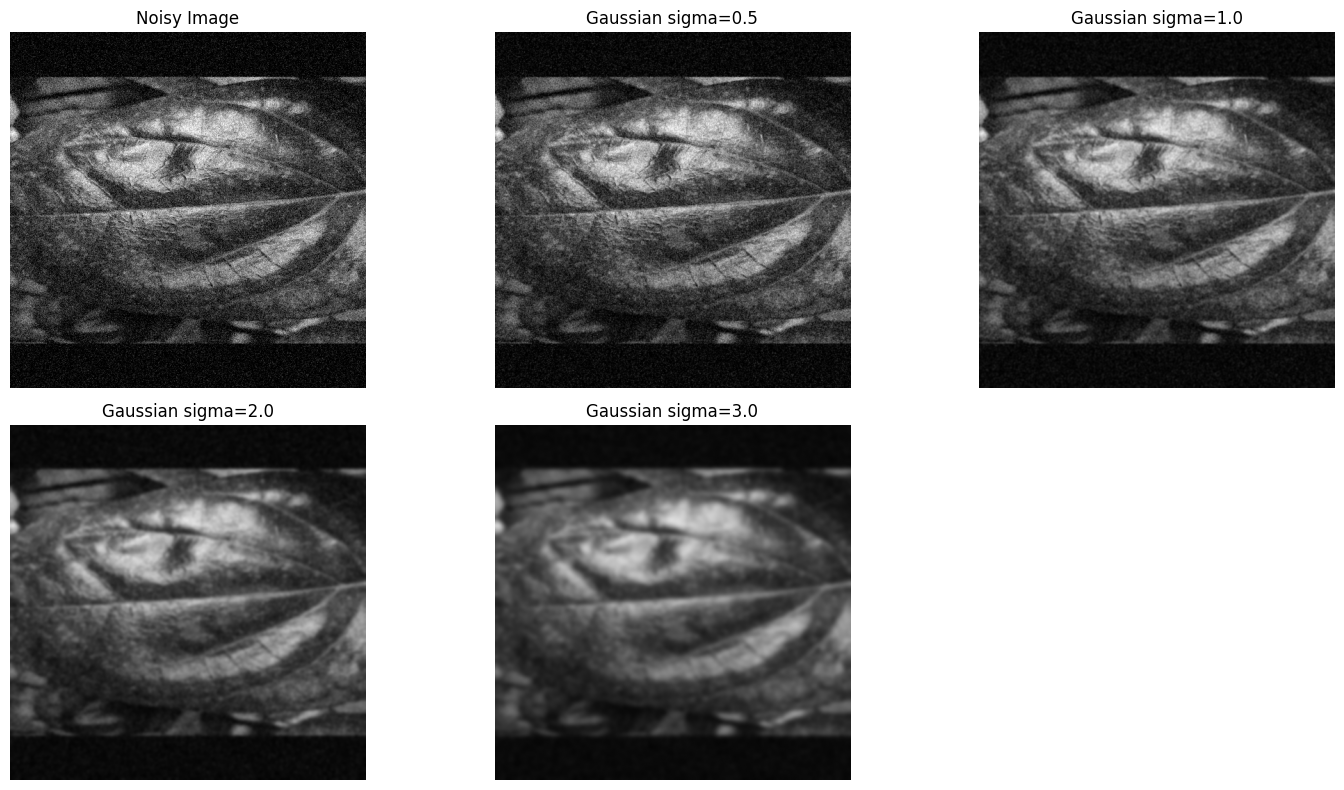

In [10]:
gaussian_sigmas = [0.5, 1.0, 2.0, 3.0]
gaussian_results = {}

for sigma in gaussian_sigmas:
    # The kernel size is selected from sigma and forced to be odd.
    k = int(6 * sigma + 1)
    if k % 2 == 0:
        k += 1
    filtered = cv2.GaussianBlur(noisy_gray, (k, k), sigmaX=sigma, sigmaY=sigma)
    gaussian_results[f"Gaussian sigma={sigma}"] = filtered
    save_gray(f"gaussian_sigma_{str(sigma).replace('.', '_')}.png", filtered)

show_images(
    [noisy_gray] + list(gaussian_results.values()),
    ["Noisy Image"] + list(gaussian_results.keys()),
    cols=3,
    figsize=(15, 8),
)

## 11. Gaussian Filter Metric Table

The table compares Gaussian smoothing at different sigma values. Students should observe how the PSNR changes as the filter moves from weak smoothing to excessive blur.

In [11]:
gaussian_metric_rows = []
for name, img in gaussian_results.items():
    gaussian_metric_rows.append({
        "Method": name,
        "MSE": mse(gray, img),
        "PSNR (dB)": psnr(gray, img),
    })

gaussian_metrics = pd.DataFrame(gaussian_metric_rows).sort_values("PSNR (dB)", ascending=False)
display(gaussian_metrics.style.format({"MSE": "{:.3f}", "PSNR (dB)": "{:.3f}"}))

,Method,MSE,PSNR (dB)
1,Gaussian sigma=1.0,95.016,28.353
2,Gaussian sigma=2.0,119.114,27.371
3,Gaussian sigma=3.0,164.009,25.982
0,Gaussian sigma=0.5,235.033,24.420


## 12. Task 4 — Apply Median Filter

Median filtering is nonlinear. Instead of averaging pixel values, it replaces the center pixel with the median value inside the local window. Although it is often very effective for salt-and-pepper noise, it can also reduce impulse-like disturbances in a Gaussian-noisy image.

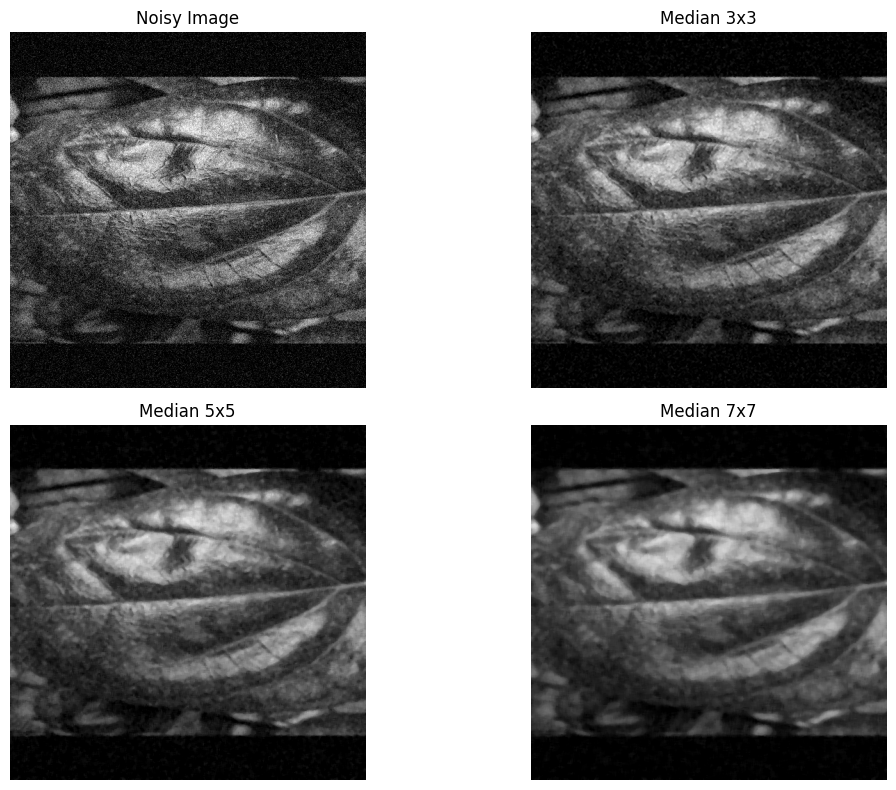

In [12]:
median_kernel_sizes = [3, 5, 7]
median_results = {}

for k in median_kernel_sizes:
    filtered = cv2.medianBlur(noisy_gray, k)
    median_results[f"Median {k}x{k}"] = filtered
    save_gray(f"median_filter_{k}x{k}.png", filtered)

show_images(
    [noisy_gray] + list(median_results.values()),
    ["Noisy Image"] + list(median_results.keys()),
    cols=2,
    figsize=(12, 8),
)

## 13. Task 5 — Evaluate All Methods Using MSE and PSNR

The following table compares the noisy image, box-filtered images, Gaussian-filtered images, and median-filtered images against the original clean grayscale reference.

In [13]:
all_results = {"Noisy Image": noisy_gray}
all_results.update(box_results)
all_results.update(gaussian_results)
all_results.update(median_results)

metric_rows = []
for name, img in all_results.items():
    metric_rows.append({
        "Method": name,
        "MSE": mse(gray, img),
        "PSNR (dB)": psnr(gray, img),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("PSNR (dB)", ascending=False).reset_index(drop=True)
display(metrics_df.style.format({"MSE": "{:.3f}", "PSNR (dB)": "{:.3f}"}))

metrics_csv_path = OUTPUT_DIR / "lab05_mse_psnr_results.csv"
metrics_df.to_csv(metrics_csv_path, index=False)
print("Saved metric table:", metrics_csv_path)

,Method,MSE,PSNR (dB)
0,Gaussian sigma=1.0,95.016,28.353
1,Median 5x5,95.660,28.324
2,Box 3x3,108.652,27.770
3,Median 7x7,110.535,27.696
4,Box 5x5,112.819,27.607
5,Median 3x3,118.703,27.386
6,Gaussian sigma=2.0,119.114,27.371
7,Gaussian sigma=3.0,164.009,25.982
8,Box 9x9,169.718,25.834
9,Gaussian sigma=0.5,235.033,24.420


Saved metric table: /kaggle/working/cse438_lab05_outputs/lab05_mse_psnr_results.csv


## 14. Visual Comparison of Best Outputs

The best output according to PSNR is selected automatically. Compare it with the original noisy image and the clean reference.

Best method by PSNR: Gaussian sigma=1.0
Best PSNR: 28.353 dB


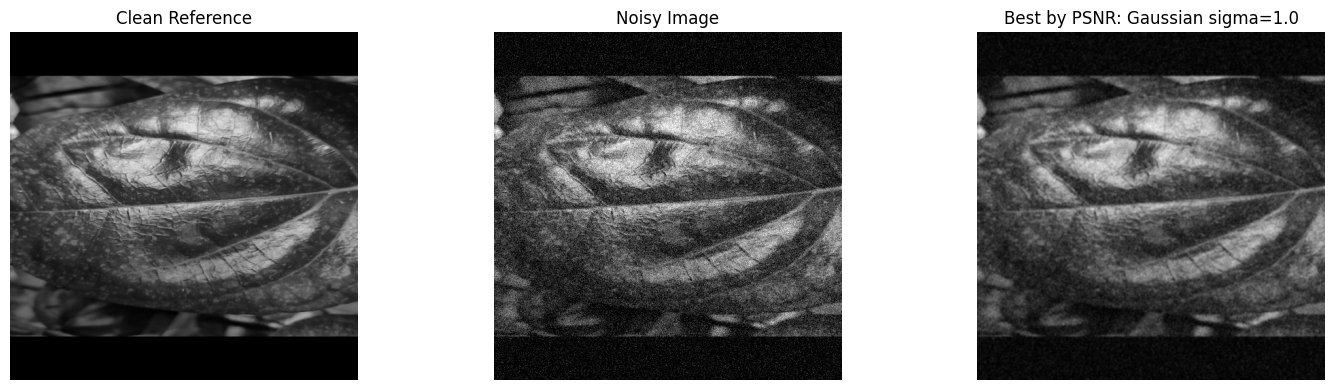

PosixPath('/kaggle/working/cse438_lab05_outputs/best_filter_output.png')

In [14]:
best_method = metrics_df.iloc[0]["Method"]
best_image = all_results[best_method]

print("Best method by PSNR:", best_method)
print("Best PSNR:", round(metrics_df.iloc[0]["PSNR (dB)"], 3), "dB")

show_images(
    [gray, noisy_gray, best_image],
    ["Clean Reference", "Noisy Image", f"Best by PSNR: {best_method}"],
    cols=3,
    figsize=(15, 4),
)

save_gray("best_filter_output.png", best_image)

## 15. PSNR Comparison Plot

This plot gives a compact view of which filtering setting produced the highest PSNR for the selected image.

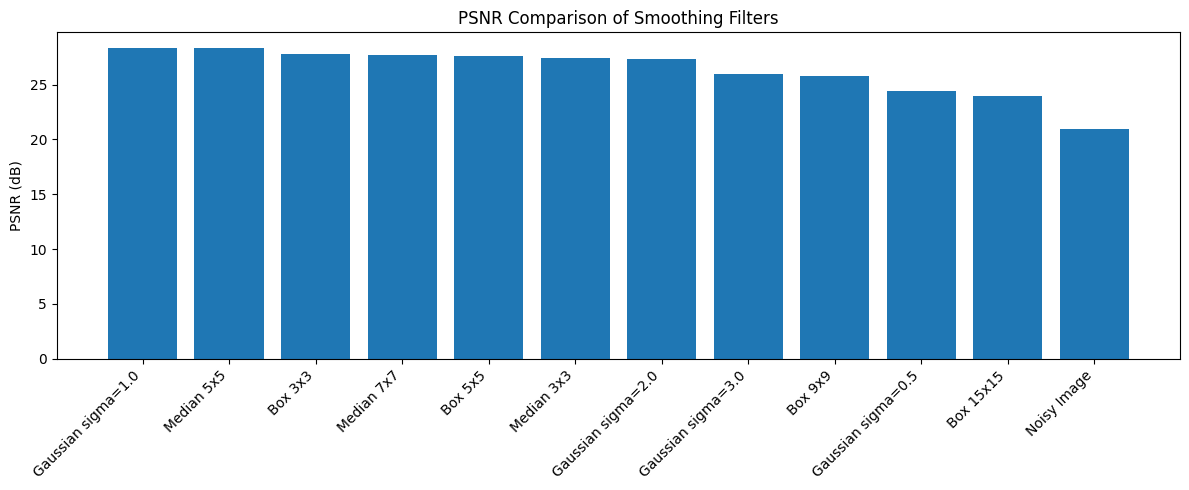

In [15]:
plt.figure(figsize=(12, 5))
plt.bar(metrics_df["Method"], metrics_df["PSNR (dB)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison of Smoothing Filters")
plt.tight_layout()
plt.show()

## 16. Discussion Guide

Use the following points while writing the lab discussion:

- How does the box filter change the leaf texture when the kernel size increases?
- Why does a Gaussian filter usually look smoother than a box filter with a similar neighborhood size?
- Did the method with the highest PSNR also preserve the visible leaf boundaries best?
- Why may median filtering behave differently from averaging filters?
- What is the practical limitation of using only MSE and PSNR for image-quality judgment?

In [16]:
# Summary:
# In this lab, we added Gaussian noise to a Betel Leaf image and applied box, Gaussian,
# and median smoothing filters. We observed that larger kernels and higher sigma values
# remove more noise but may blur leaf boundaries and surface texture. MSE and PSNR helped
# compare the filtered outputs numerically, while visual inspection remained necessary
# for judging edge preservation and practical image quality.